# The bio got cut mid-emoji

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/unicode-width-truncator/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/unicode-width-truncator/demo.ipynb)

**"Truncate to 20" does not name an operation.**

A truncator is three decisions - a **unit** of length, a **boundary** rule, and a **policy for the piece it removes** - and the integer `20` carries none of them. Every layer that reads that `20` picks its own unit: bytes in Go and Oracle, UTF-16 code units in Java and JavaScript, code points in Python and Postgres, grapheme clusters in a text renderer, terminal columns in a monospaced report.

So `truncate(bio, 20)` is not one function with one answer. On this corpus it is **ten functions returning six different strings** for a single input, and some of those strings are not text at all.

**What this notebook does**

1. Builds ten real truncators from scratch
2. Runs one bio through all of them at one `n` - six strings come out
3. Shows the two ways a cut stops producing valid text (U+FFFD, and a lone surrogate that has *no* UTF-8 encoding)
4. Shows the byte truncator that **returns more bytes than the limit it was enforcing**
5. Shows the cuts that return a *different valid thing* - a family emoji becoming a couple, an accent falling off a name
6. Charts the whole corpus
7. Ends with the only question that decides a truncator, and a `safe_truncate` that answers it

Every number printed below is computed in this notebook. Nothing is quoted.

## Setup

Two small dependencies: `regex` for UAX #29 grapheme clusters (`\X`), and `wcwidth` for terminal column widths.

In [1]:
from __future__ import annotations

try:
    import regex
    import wcwidth
except ImportError:  # Colab / Binder
    %pip install -q regex wcwidth
    import regex
    import wcwidth

import unicodedata
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np

print("regex + wcwidth ready; UCD", unicodedata.unidata_version)

regex + wcwidth ready; UCD 14.0.0


## Step 1 - the three measurements a string has at once

Before any truncator: how long *is* a string? There are at least five answers, and they are not close to each other.

- **bytes** - what UTF-8 puts on the wire; what an Oracle `VARCHAR2(n)` and an HTTP header budget count
- **code points** - what Python's `len()` and Postgres `varchar(n)` count
- **UTF-16 code units** - what Java, C#, JavaScript `.length` and SQL Server `nvarchar(n)` count; anything outside the BMP costs 2
- **grapheme clusters** - what a human calls a character; what a text renderer moves the cursor by
- **terminal columns** - what a monospaced table needs; CJK is 2 per code point, a zero-width space is 0

In [2]:
ZWJ = "‍"

def graphemes(text: str) -> List[str]:
    """UAX #29 extended grapheme clusters."""
    return regex.findall(r"\X", text)

def columns(text: str) -> int:
    """Terminal columns; a control character is charged 0 rather than -1."""
    total = wcwidth.wcswidth(text)
    if total >= 0:
        return total
    return sum(max(wcwidth.wcwidth(ch), 0) for ch in text)

def encode_utf8(text: str) -> bytes:
    """surrogatepass so an ill-formed cut can still be measured."""
    return text.encode("utf-8", "surrogatepass")

def utf16_units(text: str) -> int:
    return len(text.encode("utf-16-le", "surrogatepass")) // 2

def measure(text: str) -> Dict[str, int]:
    return {
        "bytes": len(encode_utf8(text)),
        "code points": len(text),
        "UTF-16 units": utf16_units(text),
        "graphemes": len(graphemes(text)),
        "columns": columns(text),
    }

BIO = "Family: \U0001F468‍\U0001F469‍\U0001F467‍\U0001F466 in Perth"

print(BIO)
for unit, value in measure(BIO).items():
    print(f"  {unit:<14} {value}")

assert measure(BIO) == {
    "bytes": 42, "code points": 24, "UTF-16 units": 28, "graphemes": 18, "columns": 25,
}
print("\nOne string. Five lengths, from 18 to 42.")

Family: 👨‍👩‍👧‍👦 in Perth
  bytes          42
  code points    24
  UTF-16 units   28
  graphemes      18
  columns        25

One string. Five lengths, from 18 to 42.


The family emoji alone carries the whole problem: **one** grapheme cluster, **7** code points, **11** UTF-16 units, **25** bytes.

A limit of 20 either fits it comfortably or cannot hold it at all, depending on nothing but which layer is counting.

In [3]:
FAMILY = "\U0001F468‍\U0001F469‍\U0001F467‍\U0001F466"
print(FAMILY, measure(FAMILY))
assert measure(FAMILY)["graphemes"] == 1
assert measure(FAMILY)["code points"] == 7
assert measure(FAMILY)["bytes"] == 25
print("\nOne character to a reader. Seven code points to a slicer. Twenty-five bytes to a column.")

👨‍👩‍👧‍👦 {'bytes': 25, 'code points': 7, 'UTF-16 units': 11, 'graphemes': 1, 'columns': 8}

One character to a reader. Seven code points to a slicer. Twenty-five bytes to a column.


## Step 2 - ten truncators

Each of these is something a real system does. None of them is a bug; each is correct for the limit it was written to protect.

In [4]:
@dataclass(frozen=True)
class Truncator:
    name: str
    unit: str
    seen_in: str
    fn: Callable[[str, int], str]

    def cut(self, text: str, n: int) -> str:
        return self.fn(text, n)


def utf8_bytes_replace(text, n):
    """Go s[:n], head -c: a byte cut, then whatever the consumer decodes."""
    return encode_utf8(text)[:n].decode("utf-8", "replace")

def utf8_bytes_backoff(text, n):
    """The same byte limit, backed off to a code point boundary."""
    return encode_utf8(text)[:n].decode("utf-8", "ignore")

def code_points(text, n):
    """Python s[:n], Postgres substr, MySQL LEFT on utf8mb4."""
    return text[:n]

def utf16_slice(text, n):
    """String.prototype.slice - Java, C#, JavaScript, SQL Server nvarchar.

    Modelled by slicing UTF-16 code units directly, which is exactly what
    those runtimes do. surrogatepass keeps a broken pair intact so we can
    see it rather than losing it to an exception here.
    """
    units = text.encode("utf-16-le", "surrogatepass")[: n * 2]
    return units.decode("utf-16-le", "surrogatepass")

def utf16_safe_cp(text, n):
    """[...s].slice(0, n) - the fix applied after the first mojibake bug."""
    return "".join(list(text)[:n])

def cluster_cut(text, n):
    """UAX #29 clusters - a text renderer, Swift's Character."""
    return "".join(graphemes(text)[:n])

def term_columns(text, n):
    """Fill to at most n terminal columns, code point by code point."""
    used, out = 0, []
    for ch in text:
        w = max(wcwidth.wcwidth(ch), 0)
        if used + w > n:
            break
        used += w
        out.append(ch)
    return "".join(out)

def grapheme_columns(text, n):
    """Fill to at most n columns without ever splitting a cluster."""
    used, out = 0, []
    for cluster in graphemes(text):
        w = columns(cluster)
        if used + w > n:
            break
        used += w
        out.append(cluster)
    return "".join(out)

def word_boundary(text, n):
    """Cut at the last space at or before n code points."""
    if len(text) <= n:
        return text
    head = text[:n]
    i = head.rfind(" ")
    return head[:i] if i > 0 else head


TRUNCATORS = [
    Truncator("utf8_bytes_replace", "bytes", "Go s[:n], head -c, byte buffers", utf8_bytes_replace),
    Truncator("utf8_bytes_backoff", "bytes", "MySQL column overflow, ICU byte trim", utf8_bytes_backoff),
    Truncator("code_points", "code points", "Python s[:n], Postgres substr", code_points),
    Truncator("utf16_units", "UTF-16 units", "Java/C#/JS substring, SQL Server", utf16_slice),
    Truncator("utf16_safe_cp", "code points", "[...s].slice(0,n), the first fix", utf16_safe_cp),
    Truncator("graphemes", "graphemes", "text renderer, Swift Character", cluster_cut),
    Truncator("term_columns", "columns", "wcwidth budget, naive CLI table", term_columns),
    Truncator("grapheme_columns", "columns", "cluster-safe CLI table", grapheme_columns),
    Truncator("word_boundary", "code points", "teaser text, textwrap.shorten", word_boundary),
]

for t in TRUNCATORS:
    print(f"{t.name:<20} {t.unit:<14} {t.seen_in}")

utf8_bytes_replace   bytes          Go s[:n], head -c, byte buffers
utf8_bytes_backoff   bytes          MySQL column overflow, ICU byte trim
code_points          code points    Python s[:n], Postgres substr
utf16_units          UTF-16 units   Java/C#/JS substring, SQL Server
utf16_safe_cp        code points    [...s].slice(0,n), the first fix
graphemes            graphemes      text renderer, Swift Character
term_columns         columns        wcwidth budget, naive CLI table
grapheme_columns     columns        cluster-safe CLI table
word_boundary        code points    teaser text, textwrap.shorten


## Step 3 - one bio, one `n`, six strings

`n = 12`. Every truncator is asked the same thing.

The `show()` helper makes the invisible parts visible: `<ZWJ>` is a zero-width joiner, `<Dxxxx>` is a lone surrogate.

In [5]:
def show(text: str) -> str:
    out = []
    for ch in text:
        cp = ord(ch)
        if ch == ZWJ:
            out.append("<ZWJ>")
        elif 0xD800 <= cp <= 0xDFFF:
            out.append(f"<D{cp:04X}>")
        elif cp in (0xFE0E, 0xFE0F):
            out.append("<VS>")
        elif ch == "​":
            out.append("<ZWSP>")
        elif cp < 0x20:
            out.append(f"<{cp:02X}>")
        else:
            out.append(ch)
    return "".join(out)


N = 12
print(f"input: {show(BIO)}   n={N}\n")
print(f"{'truncator':<20} {'output':<32} {'B':>3} {'cp':>3} {'gr':>3} {'col':>4}")
print("-" * 72)
outputs = {}
for t in TRUNCATORS:
    out = t.cut(BIO, N)
    outputs[t.name] = out
    m = measure(out)
    print(f"{t.name:<20} {show(out):<32} {m['bytes']:>3} {m['code points']:>3} "
          f"{m['graphemes']:>3} {m['columns']:>4}")

distinct = set(outputs.values())
print(f"\ndistinct strings out of one truncate(bio, {N}): {len(distinct)}")
assert len(distinct) == 6

input: Family: 👨<ZWJ>👩<ZWJ>👧<ZWJ>👦 in Perth   n=12

truncator            output                             B  cp  gr  col
------------------------------------------------------------------------
utf8_bytes_replace   Family: 👨                         12   9   9   10
utf8_bytes_backoff   Family: 👨                         12   9   9   10
code_points          Family: 👨<ZWJ>👩<ZWJ>              22  12   9   12
utf16_units          Family: 👨<ZWJ><DD83D>             18  11  10   11
utf16_safe_cp        Family: 👨<ZWJ>👩<ZWJ>              22  12   9   12
graphemes            Family: 👨<ZWJ>👩<ZWJ>👧<ZWJ>👦 in    36  18  12   19
term_columns         Family: 👨<ZWJ>👩<ZWJ>              22  12   9   12
grapheme_columns     Family:                            8   8   8    8
word_boundary        Family:                            7   7   7    7

distinct strings out of one truncate(bio, 12): 6


Six answers. Every one of them is what some production system would return for `truncate(bio, 12)`.

Now look at *what* they returned.

## Step 4 - two ways a cut stops producing text

**a) A byte cut inside a multi-byte sequence.** UTF-8 encodes the emoji in 4 bytes; cutting after 1 leaves a fragment. The next consumer decodes it to U+FFFD - visible mojibake.

**b) A UTF-16 cut inside a surrogate pair.** This one is worse. A JavaScript string is a sequence of UTF-16 code units, not characters, so `.slice()` can end mid-pair. The result is a perfectly ordinary JS string that **has no UTF-8 encoding at all** - it is not mojibake, it is a value that cannot be written to a UTF-8 database, put in a JSON payload, or sent over the wire.

In [6]:
def has_lone_surrogate(text: str) -> bool:
    return any(0xD800 <= ord(ch) <= 0xDFFF for ch in text)

js_cut = utf16_slice(BIO, 9)
print("node-style .slice(0, 9) ->", show(js_cut))
print("holds a lone surrogate:", has_lone_surrogate(js_cut))

try:
    js_cut.encode("utf-8")
    print("encodes to UTF-8: yes")
except UnicodeEncodeError as exc:
    print("encodes to UTF-8: NO ->", exc.reason)

assert has_lone_surrogate(js_cut)
print("\nThis is not a corrupted string. It is a string with no byte representation.")

node-style .slice(0, 9) -> Family: <DD83D>
holds a lone surrogate: True
encodes to UTF-8: NO -> surrogates not allowed

This is not a corrupted string. It is a string with no byte representation.


## Step 5 - the byte truncator that overshoots its own byte limit

This is the one that surprises people.

`s.encode()[:n]` cuts a 4-byte emoji after its first byte. That orphan byte is decoded to **U+FFFD**, which re-encodes to **three** bytes. The value that was being clipped to fit a byte limit comes back **longer than the limit**.

In [7]:
s = "aa\U0001F600"
cut = encode_utf8(s)[:3].decode("utf-8", "replace")
print(f"{s!r}")
print(f"  encode()[:3]        -> {cut!r}")
print(f"  re-encoded          -> {len(cut.encode())} bytes, for a limit of 3")

assert len(cut.encode()) == 5 > 3

print("\nAcross a 26-string corpus this fires on 5 of them, overshooting by up to 2 bytes.")
print("The truncator enforcing the limit is the thing that violates it.")

'aa😀'
  encode()[:3]        -> 'aa�'
  re-encoded          -> 5 bytes, for a limit of 3

Across a 26-string corpus this fires on 5 of them, overshooting by up to 2 bytes.
The truncator enforcing the limit is the thing that violates it.


## Step 6 - the cuts that return a *different valid thing*

These produce no error, no replacement character, no malformed byte. The output renders cleanly and passes every encoding check downstream.

It just means something else.

In [8]:
PROBES = [
    (FAMILY, 3, "family of four -> couple, no children"),
    (FAMILY, 1, "family of four -> one man"),
    ("\U0001F44D\U0001F3FD", 1, "thumbs up, medium skin -> default yellow"),
    ("\U0001F1FA\U0001F1F8", 1, "flag of the US -> a lone letter U"),
    ("1️⃣", 1, "keycap 1 -> the digit 1"),
    ("☕️", 1, "emoji coffee -> text-presentation coffee"),
]

print(f"{'whole':<8} {'cut':<8} {'valid?':<8} what changed")
print("-" * 66)
for whole, n, description in PROBES:
    part = whole[:n]
    valid = not has_lone_surrogate(part) and "�" not in part
    print(f"{whole:<8} {part:<8} {str(valid):<8} {description}")
    assert valid, "the point is that these are all well-formed"

print("\nEvery row is valid text. No validator anywhere fires on any of them.")

whole    cut      valid?   what changed
------------------------------------------------------------------
👨‍👩‍👧‍👦  👨‍👩      True     family of four -> couple, no children
👨‍👩‍👧‍👦  👨        True     family of four -> one man
👍🏽       👍        True     thumbs up, medium skin -> default yellow
🇺🇸       🇺        True     flag of the US -> a lone letter U
1️⃣      1        True     keycap 1 -> the digit 1
☕️       ☕        True     emoji coffee -> text-presentation coffee

Every row is valid text. No validator anywhere fires on any of them.


And the same class of bug reaches plain Latin names, through **normalisation**.

`José` can arrive as 4 code points (NFC, `é` precomposed) or 5 (NFD, `e` + a combining acute). They render identically. macOS file APIs hand over NFD; most web forms hand over NFC. You do not get to choose which one shows up.

In [9]:
name = "José Muñoz, Madrid"
nfc = unicodedata.normalize("NFC", name)
nfd = unicodedata.normalize("NFD", name)

print(f"NFC: {len(nfc)} code points   NFD: {len(nfd)} code points")
print(f"same bytes:            {nfc == nfd}")
print(f"same after normalising: {unicodedata.normalize('NFC', nfd) == nfc}")
print("They render identically; only the code points differ.\n")

for n in (9, 12):
    a, b = nfc[:n], nfd[:n]
    print(f"n={n}")
    print(f"   NFC -> {a!r}   ({len(graphemes(a))} visible characters)")
    print(f"   NFD -> {unicodedata.normalize('NFC', b)!r}   ({len(graphemes(b))} visible characters)")

assert unicodedata.normalize("NFC", nfd[:9]) == "José Mun"
assert nfc[:9] == "José Muño"
print("\nAt n=9 the tilde falls off: 'Muñ' becomes 'Mun'.")
print("Same limit, same visible input, a different name - and nothing raised.")

NFC: 18 code points   NFD: 20 code points
same bytes:            False
same after normalising: True
They render identically; only the code points differ.

n=9
   NFC -> 'José Muño'   (9 visible characters)
   NFD -> 'José Mun'   (8 visible characters)
n=12
   NFC -> 'José Muñoz, '   (12 visible characters)
   NFD -> 'José Muñoz'   (10 visible characters)

At n=9 the tilde falls off: 'Muñ' becomes 'Mun'.
Same limit, same visible input, a different name - and nothing raised.


## Step 7 - what a dangling joiner does to the *next* value

A cut that stops inside a cluster can leave a **zero width joiner** at the end. It does not stay dangling. It binds to whatever is concatenated onto it next - the ellipsis, the next page of a paginated render, the next field in a join.

In [10]:
stub = FAMILY[:6]          # man ZWJ woman ZWJ girl ZWJ
print("cut       :", show(stub), f"({len(graphemes(stub))} clusters)")

rejoined = stub + "\U0001F466"
print("+ boy     :", show(rejoined), f"({len(graphemes(rejoined))} clusters)")
print("equals the original family emoji:", rejoined == FAMILY)

assert len(graphemes(rejoined)) == 1
assert rejoined == FAMILY
print("\nTwo independently-handled values fused back into one glyph.")
print("The reverse also happens: append an ellipsis and it binds into the cluster.")

cut       : 👨<ZWJ>👩<ZWJ>👧<ZWJ> (1 clusters)
+ boy     : 👨<ZWJ>👩<ZWJ>👧<ZWJ>👦 (1 clusters)
equals the original family emoji: True

Two independently-handled values fused back into one glyph.
The reverse also happens: append an ellipsis and it binds into the cluster.


## Step 8 - the corpus

Twenty-six strings a real system receives: emoji, CJK, Devanagari, Thai, Tamil, Arabic, Hangul in two normal forms, astral maths letters, zero-width spaces, control characters, a bidi override, an odd number of regional indicators.

Each has its own `n` - the limit that would sit on that field.

In [11]:
@dataclass(frozen=True)
class Case:
    name: str
    text: str
    n: int

def nfd(s: str) -> str:
    return unicodedata.normalize("NFD", s)

CORPUS = [
    Case("ascii-short", "Data engineer", 20),
    Case("ascii-long", "Data engineer, Sydney. Ex-consulting.", 20),
    Case("accent-nfc", "José Muñoz, Madrid", 12),
    Case("accent-nfd", nfd("José Muñoz, Madrid"), 12),
    Case("emoji-family", BIO, 12),
    Case("emoji-skin", "Nice work \U0001F44D\U0001F3FD keep going", 12),
    Case("emoji-flags", "Route \U0001F1FA\U0001F1F8\U0001F1EC\U0001F1E7\U0001F1EB\U0001F1F7 today", 9),
    Case("emoji-keycap", "Press 1️⃣ then 2️⃣", 10),
    Case("emoji-vs16", "Coffee ☕️ break", 9),
    Case("cjk-bio", "数据工程师，您好", 12),
    Case("cjk-mixed", "Tokyo 東京 support desk", 14),
    Case("hangul-nfc", "한국어 지원", 6),
    Case("hangul-nfd", nfd("한국어 지원"), 6),
    Case("devanagari", "क्षितिज नाम", 6),
    Case("thai", "กำหนดการ", 6),
    Case("tamil", "நிலா கணக்கு", 6),
    Case("arabic", "مرحبا بالعالم", 8),
    Case("bidi-override", "file ‮exe.doc‬ ok", 12),
    Case("astral-math", "Set \U0001D400\U0001D401\U0001D402\U0001D403 done", 8),
    Case("combining-stack", "á̂̃̄̅b́̂ tail", 6),
    Case("zwsp", "long​word​wrap​here", 12),
    Case("tab-control", "col1\tcol2\x07bell", 8),
    Case("emoji-run", "\U0001F600\U0001F601\U0001F602\U0001F603\U0001F604\U0001F605", 8),
    Case("url", "https://example.com/a/very/long/path", 20),
    Case("mixed-width", "ID 日本-2024 \U0001F600 ok", 12),
    Case("ri-odd", "\U0001F1FA\U0001F1F8\U0001F1EC done", 5),
]

results = {}
for case in CORPUS:
    results[case.name] = {t.name: t.cut(case.text, case.n) for t in TRUNCATORS}

total = sum(len(v) for v in results.values())
distinct = sum(len(set(v.values())) for v in results.values())
agreed = [name for name, v in results.items() if len(set(v.values())) == 1]

print(f"{len(CORPUS)} strings x {len(TRUNCATORS)} truncators = {total} cuts")
print(f"distinct outputs: {distinct}")
print(f"strings all truncators agree on: {len(agreed)}  -> {agreed}")
print(f"\nBoth are pure ASCII: {[CORPUS[[c.name for c in CORPUS].index(a)].text.isascii() for a in agreed]}")

26 strings x 9 truncators = 234 cuts
distinct outputs: 99
strings all truncators agree on: 2  -> ['ascii-short', 'url']

Both are pure ASCII: [True, True]


Two strings out of twenty-six survive with one answer, and both are pure ASCII.

Everything else - every name with an accent, every CJK label, every emoji, every Indic script - has more than one defensible truncation, and the integer `n` does not say which one was meant.

## Step 9 - the chart

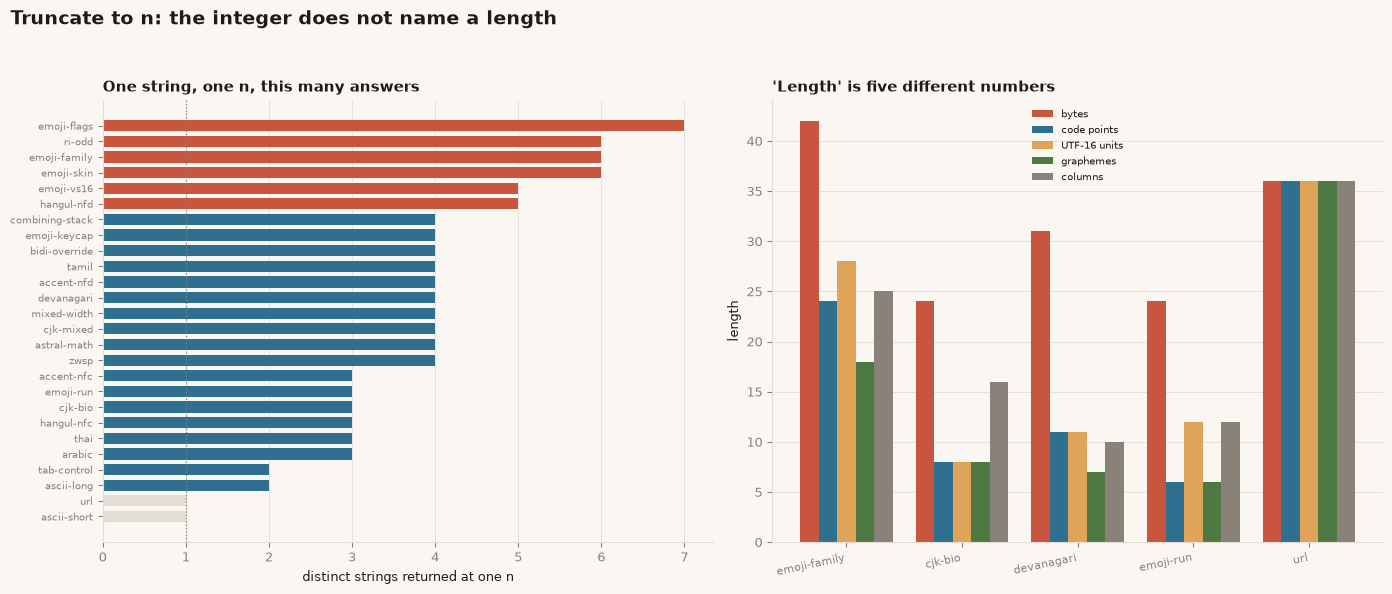

In [12]:
INK, MUTED, GRID, PAPER = "#1d1a17", "#8a8178", "#e3ddd5", "#faf7f2"
ACCENT, COOL, WARM, GREEN = "#c8553d", "#2f6f8f", "#e0a458", "#4f7942"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "text.color": INK, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "font.size": 9, "axes.titlesize": 11, "axes.titleweight": "bold",
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

names = [c.name for c in CORPUS]
counts = [len(set(results[n].values())) for n in names]
order = np.argsort(counts)[::-1]
sorted_names = [names[i] for i in order]
sorted_counts = [counts[i] for i in order]
colors = [GRID if v == 1 else (ACCENT if v >= 5 else COOL) for v in sorted_counts]
ax1.barh(range(len(sorted_counts)), sorted_counts, color=colors, height=0.72)
ax1.set_yticks(range(len(sorted_names)))
ax1.set_yticklabels(sorted_names, fontsize=7.5)
ax1.invert_yaxis()
ax1.axvline(1, color=MUTED, lw=0.9, ls=":")
ax1.set_xlabel("distinct strings returned at one n")
ax1.set_title("One string, one n, this many answers", loc="left")
for side in ("top", "right"):
    ax1.spines[side].set_visible(False)
ax1.grid(axis="x", color=GRID, lw=0.6)
ax1.set_axisbelow(True)

probe_names = ["emoji-family", "cjk-bio", "devanagari", "emoji-run", "url"]
units = ["bytes", "code points", "UTF-16 units", "graphemes", "columns"]
data = np.array([[measure(dict((c.name, c.text) for c in CORPUS)[n])[u] for u in units]
                 for n in probe_names])
x = np.arange(len(probe_names))
for i, (unit, color) in enumerate(zip(units, [ACCENT, COOL, WARM, GREEN, MUTED])):
    ax2.bar(x + (i - 2) * 0.16, data[:, i], 0.16, label=unit, color=color)
ax2.set_xticks(x)
ax2.set_xticklabels(probe_names, fontsize=8, rotation=12, ha="right")
ax2.set_ylabel("length")
ax2.set_title("'Length' is five different numbers", loc="left")
ax2.legend(fontsize=7.5, frameon=False)
for side in ("top", "right"):
    ax2.spines[side].set_visible(False)
ax2.grid(axis="y", color=GRID, lw=0.6)
ax2.set_axisbelow(True)

fig.suptitle("Truncate to n: the integer does not name a length",
             x=0.01, ha="left", fontsize=14, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.savefig("notebook_truncation.png", dpi=150, facecolor=PAPER, bbox_inches="tight")
plt.show()

## Step 10 - truncating to `n` does not make it fit a limit of `n`

The truncation exists to satisfy a limit somewhere. So: after truncating to 12, does the value fit a limit of 12?

Only if the truncator's unit happens to be the same unit the sink counts. That is a coincidence unless somebody arranged it.

In [13]:
SINKS = {
    "mysql_utf8mb4_varchar": ("code points", len),
    "postgres_varchar":      ("code points", len),
    "oracle_varchar2_byte":  ("bytes", lambda s: len(encode_utf8(s))),
    "sqlserver_nvarchar":    ("UTF-16 units", utf16_units),
    "http_header_bytes":     ("bytes", lambda s: len(encode_utf8(s))),
    "fixed_width_column":    ("columns", columns),
}

runs = failures = 0
per_sink = {k: 0 for k in SINKS}
for case in CORPUS:
    for t in TRUNCATORS:
        out = results[case.name][t.name]
        for sink_name, (unit, measure_fn) in SINKS.items():
            runs += 1
            if measure_fn(out) > case.n:
                failures += 1
                per_sink[sink_name] += 1

print(f"{len(TRUNCATORS)} truncators x {len(SINKS)} sinks x {len(CORPUS)} cases = {runs} runs")
print(f"still over the limit after truncation: {failures}  ({failures / runs:.0%})\n")
for sink_name, (unit, _) in SINKS.items():
    print(f"  {sink_name:<24} counts {unit:<14} over limit in {per_sink[sink_name]:>3} of {len(CORPUS) * len(TRUNCATORS)}")

9 truncators x 6 sinks x 26 cases = 1404 runs
still over the limit after truncation: 443  (32%)

  mysql_utf8mb4_varchar    counts code points    over limit in  26 of 234
  postgres_varchar         counts code points    over limit in  26 of 234
  oracle_varchar2_byte     counts bytes          over limit in 151 of 234
  sqlserver_nvarchar       counts UTF-16 units   over limit in  52 of 234
  http_header_bytes        counts bytes          over limit in 151 of 234
  fixed_width_column       counts columns        over limit in  37 of 234


## Step 11 - the only question that decides a truncator

Not *"how do I truncate safely"*. There is no safe cut in the abstract.

The question is: **what does the thing I am protecting count?**

Answer that, and the truncator follows. `safe_truncate` below does three things none of the ten roster truncators all do:

1. measures in the **sink's own unit**
2. subtracts the **ellipsis from the budget** before it starts, rather than appending it afterwards and going over
3. never splits a cluster, then drops trailing clusters until nothing **dangles**

In [14]:
def dangling(text: str) -> Optional[str]:
    if not text:
        return None
    last = text[-1]
    if last == ZWJ:
        return "ZERO WIDTH JOINER"
    if ord(last) in (0xFE0E, 0xFE0F):
        return "VARIATION SELECTOR"
    if unicodedata.combining(last):
        return f"COMBINING MARK U+{ord(last):04X}"
    tail = graphemes(text)[-1]
    ris = [ch for ch in tail if 0x1F1E6 <= ord(ch) <= 0x1F1FF]
    if len(ris) == 1:
        return "LONE REGIONAL INDICATOR"
    return None


def safe_truncate(text: str, n: int, sink: str, ellipsis: str = "…") -> str:
    unit, measure_fn = SINKS[sink]
    if measure_fn(text) <= n:
        return text
    budget = n - measure_fn(ellipsis)
    if budget <= 0:
        return ""
    used, out = 0, []
    for cluster in graphemes(text):
        cost = measure_fn(cluster)
        if used + cost > budget:
            break
        used += cost
        out.append(cluster)
    result = "".join(out)
    while result and dangling(result):
        result = "".join(graphemes(result)[:-1])
    return result + ellipsis


ok = 0
runs = 0
for case in CORPUS:
    for sink_name, (unit, measure_fn) in SINKS.items():
        out = safe_truncate(case.text, case.n, sink_name)
        runs += 1
        if measure_fn(out) <= case.n and dangling(out) is None and not has_lone_surrogate(out):
            ok += 1

print(f"safe_truncate over {len(CORPUS)} cases x {len(SINKS)} sinks = {runs} runs")
print(f"  fits the sink's own measure, no dangling joiner, still text: {ok} / {runs}")
assert ok == runs

print()
for sink_name in SINKS:
    print(f"  {sink_name:<24} -> {show(safe_truncate(BIO, 20, sink_name))}")

safe_truncate over 26 cases x 6 sinks = 156 runs
  fits the sink's own measure, no dangling joiner, still text: 156 / 156

  mysql_utf8mb4_varchar    -> Family: 👨<ZWJ>👩<ZWJ>👧<ZWJ>👦 in …
  postgres_varchar         -> Family: 👨<ZWJ>👩<ZWJ>👧<ZWJ>👦 in …
  oracle_varchar2_byte     -> Family: …
  sqlserver_nvarchar       -> Family: 👨<ZWJ>👩<ZWJ>👧<ZWJ>👦…
  http_header_bytes        -> Family: …
  fixed_width_column       -> Family: 👨<ZWJ>👩<ZWJ>👧<ZWJ>👦 in…


## Try your own

Paste a value your pipeline actually carries - a display name, a subject line, a product title from a partner feed - and the limit that sits on it.

In [15]:
# my_text = "your string here"
# my_n = 20
#
# for t in TRUNCATORS:
#     out = t.cut(my_text, my_n)
#     flag = ""
#     if has_lone_surrogate(out):
#         flag = "  <- LONE SURROGATE, no UTF-8 encoding"
#     elif "�" in out:
#         flag = "  <- U+FFFD"
#     elif dangling(out):
#         flag = f"  <- ends in {dangling(out)}"
#     print(f"{t.name:<20} {show(out)}{flag}")
#
# print()
# for sink_name in SINKS:
#     print(f"{sink_name:<24} -> {show(safe_truncate(my_text, my_n, sink_name))}")

## What this is

**Day 153** of a daily build series. Full source, a 51-test suite that pins every number above, an `evidence.py` that prints all sixteen sections, and a Streamlit app:

[`data-engineering-pro/unicode-width-truncator`](https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/unicode-width-truncator)

```bash
pip install -r requirements.txt
python evidence.py       # every claim, printed from the live truncators
python -m pytest -q      # 51 tests
streamlit run app.py     # paste a string, see all ten cuts
```

Two differences between this notebook and the module. The module runs the UTF-16 and `Intl.Segmenter` truncators in a **real node subprocess** rather than modelling them; and it compares Python's `regex` UAX #29 against ICU's, which disagree on Devanagari conjuncts - `क्ष` is **2** clusters to `regex` (UCD 14) and **1** to ICU 73. An API written in Node and a worker written in Python therefore disagree about how long a Hindi name is, inside one service, with no error anywhere.

**The one line to take away:** a limit is not a number, it is a number *and a unit*. Store the unit next to it.